# Biplanar X-ray to CT Reconstruction with CINDER

Reconstruct a chest CT volume from two orthogonal X-rays, a posterior-anterior
(PA) and a lateral view. As in [SPIDER](https://arxiv.org/abs/2507.04684), a 2D
UNet encodes each X-ray, every voxel reads the features at its projections onto
both views, and an MLP decodes them with a code of the voxel. We compare
SPIDER's hash code with CINDER's FUTON code on a sinc or a Lanczos basis, the
hash and sinc codes also with CINDER's weight modulation, and
[PerX2CT](https://arxiv.org/abs/2303.05297), which decodes slices instead of
voxels.

## Setup

In [1]:
import multiprocessing as mp
import os
import time
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from ignite.metrics import PSNR, SSIM
from matplotlib.ticker import LogLocator, NullFormatter
from torch import nn
from torch.utils.data import DataLoader

import biplanar as bp
import cinder as cd

sns.set_theme(
    style="ticks",
    rc={
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Data

The CT scans are the first 400 patients of
[LIDC-IDRI](https://www.cancerimagingarchive.net/collection/lidc-idri/), about
30 GB to download. As in X2CT-GAN, each scan is resampled onto a 320 mm cube of
128³ voxels, clipped to $[-1000, 1500]$ HU and scaled to $[0, 1]$.
[DiffDRR](https://github.com/eigenvivek/DiffDRR) renders its X-rays with the
perspective projection of a source 1.5 m from the patient and a 43 cm detector
1.8 m from the source.

In [2]:
LIDC_DIR = Path(os.environ.get("LIDC_DIR", "/scratch/data/LIDC-IDRI/dicom"))
CACHE_DIR = LIDC_DIR.parent / "biplanar128"
SIZE, SIDE = 128, 320.0  # 128³ voxels over 320 mm, and 128² X-ray pixels

rig = bp.Biplane(
    SIZE, SIDE, source_distance=1500.0, sdd=1800.0, height=SIZE, pixel=430.0 / SIZE
)


def load(folder):
    hu, geometry = bp.read_series(folder)
    return folder.name, bp.resample_to_cube(hu, geometry, SIZE, SIDE)


if len(list(LIDC_DIR.glob("LIDC-IDRI-*"))) < 400:
    bp.download_lidc(LIDC_DIR, num_patients=400)
folders = sorted(LIDC_DIR.glob("LIDC-IDRI-*"))
todo = [folder for folder in folders if not (CACHE_DIR / f"{folder.name}.npz").exists()]
CACHE_DIR.mkdir(parents=True, exist_ok=True)
with mp.get_context("fork").Pool(8) as pool:  # resample on the CPU, render on the GPU
    for name, cube in pool.imap(load, todo):
        volume = bp.normalize_hu(cube).astype(np.float16)
        np.savez_compressed(
            CACHE_DIR / f"{name}.npz",
            volume=volume,
            xrays=rig.render(cube, device).numpy(),
        )

files = [CACHE_DIR / f"{folder.name}.npz" for folder in folders]
train_set = bp.BiplanarDataset(files[:288])
val_set = bp.BiplanarDataset(files[288:320])
test_set = bp.BiplanarDataset(files[320:])
train_loader = DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    drop_last=True,
    pin_memory=True,
)
val_loader = DataLoader(val_set, batch_size=1, num_workers=4)
test_loader = DataLoader(test_set, batch_size=1, num_workers=4)
print(
    f"Patients: {len(train_set)} train, {len(val_set)} validation, {len(test_set)} test"
)

Patients: 288 train, 32 validation, 80 test


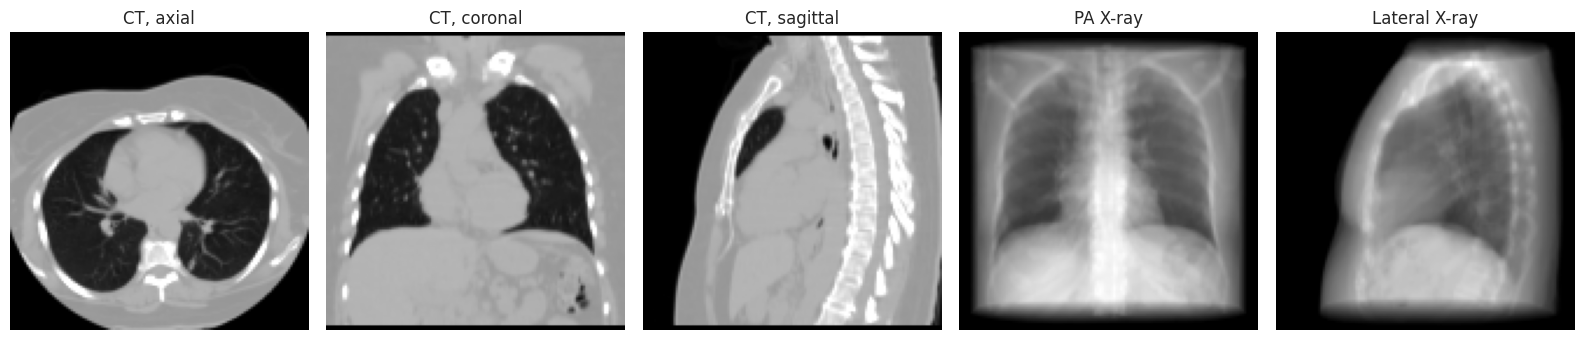

In [3]:
WINDOW = dict(cmap="gray", vmin=0.0, vmax=0.6)  # -1000 to 500 HU
PLANES = {  # central slices of a (z, y, x) volume, the head up
    "Axial": lambda v: v[SIZE // 2],
    "Coronal": lambda v: v[:, SIZE // 2].flip(0),
    "Sagittal": lambda v: v[:, :, SIZE // 2].flip(0),
}

xrays, volume = test_set[7]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, (plane, cut) in zip(axes, PLANES.items()):
    ax.imshow(cut(volume[0]), **WINDOW)
    ax.set_title(f"CT, {plane.lower()}")
for ax, image, view in zip(axes[3:], xrays, ("PA", "Lateral")):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{view} X-ray")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Model Configurations

All models share SPIDER's view encoder, a 2D UNet run on each X-ray, and read
its maps where a point projects onto each view, through pinhole cameras
fitted to DiffDRR. The point-wise models are `cinder.CINDER` decoders of the
128³ grid with the same ReLU MLP: `FeatureConcat` concatenates the sampled
features with a code of the point, as SPIDER does, and weight modulation gives
each patient its own MLP. `# deviation` comments mark the changes to the
published models.

In [4]:
pa, lateral = rig.cameras()
SAMPLE_AT = [pa, pa, lateral, lateral]  # per view, its full map, then its bottleneck
ENCODER = partial(bp.BiplanarUNet, out_channels=32)
INR = partial(cd.MLP, hidden_features=256, hidden_layers=3)
HASH = partial(  # SPIDER's L = 11 levels of F = 8 features
    cd.HashEncoding,
    num_levels=11,
    features_per_level=8,
    log2_hashmap_size=16,
    base_resolution=16,
    max_resolution=SIZE,
)
SINC = partial(  # two sinc components per voxel and axis, and CP rank 512
    cd.FUTONEncoding,
    basis=("sinc", {"num_components": 256, "grid_size": [SIZE] * 3}),
    combiner=("cp", {"rank": 512}),
)
LANCZOS = partial(  # the same with Lanczos-3 components, six of them per point
    cd.FUTONEncoding,
    basis=("lanczos", {"num_components": 256, "radius": 3}),
    combiner=("cp", {"rank": 512}),
)
# Weight modulation conditions on both bottlenecks.
WEIGHTS = ("displacement", {"conditioner": "mlp", "cond_maps": (1, 3)})


def concat(code):
    return ("concat", {"encoding": code, "sample_at": SAMPLE_AT})


def with_weights(modulator):
    return partial(cd.ListModulators, modulators=[WEIGHTS, modulator])


point_model = partial(
    cd.CINDER,
    in_channels=2,
    out_channels=1,
    encoder=ENCODER,
    inr=INR,
    in_size=(SIZE, SIZE),
    out_size=(SIZE, SIZE, SIZE),
    sampling_ratio=0.1,  # voxels decoded per training step
    chunk_size=2**18,
)

CONFIGS = [
    {
        "name": "PerX2CT",  # Kyung et al. (ICASSP 2023)
        # deviation: the shared UNet replaces the paper's ResNet-101, and the
        # L1 loss its MSE and perceptual losses.
        "model": partial(bp.PerX2CT, ENCODER, SAMPLE_AT, size=SIZE),
        "lr": 1e-4,
    },
    {
        "name": "SPIDER",
        # deviation: no structure branch, since LIDC-IDRI has no organ masks.
        "model": partial(point_model, modulator=concat(HASH)),
        "lr": 3e-4,
    },
    {
        "name": "SPIDER + weight modulation",
        "model": partial(point_model, modulator=with_weights(concat(HASH))),
        "lr": 3e-4,
    },
    {
        "name": "FUTON-sinc",
        "model": partial(point_model, modulator=concat(SINC)),
        "lr": 3e-4,
    },
    {
        "name": "FUTON-sinc + weight modulation",
        "model": partial(point_model, modulator=with_weights(concat(SINC))),
        "lr": 3e-4,
    },
    {
        "name": "FUTON-lanczos",
        "model": partial(point_model, modulator=concat(LANCZOS)),
        "lr": 3e-4,
    },
]

## Train Models

Every model trains with `cinder.fit` for 1000 iterations of 4 patients, with the
recipe of the configs: AdamW, a 1% warmup and a cosine schedule, under bfloat16
autocast. A step scores 10% of the voxels, or 12 slices for PerX2CT, with the L1
loss, and the validation patients are reconstructed every 100 iterations. The
throughput is the median rate of reconstructing a test patient's volume.

In [5]:
def clamp(output):  # intensities lie in [0, 1]
    predictions, targets = output
    return predictions.clamp(0, 1), targets


def metrics():
    return {
        "PSNR (dB)": PSNR(1.0, clamp),
        "SSIM": SSIM(1.0, output_transform=clamp, ndims=3),
    }


@torch.no_grad()
def reconstruct(model, xrays):
    model.eval()
    with torch.autocast(
        device.type, dtype=torch.bfloat16, enabled=device.type == "cuda"
    ):
        return model(xrays[None].to(device))[0, 0].float().clamp(0, 1).cpu()


def throughput(model, xrays, repeats=10):
    durations = []
    for _ in range(repeats + 1):  # the first warms up
        start = time.perf_counter()
        reconstruct(model, xrays)  # the copy to the CPU waits for the GPU
        durations.append(time.perf_counter() - start)
    return 1 / np.median(durations[1:])


results = []

for config in CONFIGS:
    torch.manual_seed(0)
    model = config["model"]()
    num_params = sum(p.numel() for p in model.parameters())

    print(f"\n--- {config['name']} ({num_params:,} params) ---")
    history = cd.fit(
        model,
        cd.SampledLoss(nn.L1Loss(), model),
        train_loader,
        max_iters=1000,
        lr=config["lr"],
        val_loader=val_loader,
        metrics=metrics(),
        eval_interval=100,
        log_interval=50,
        device=device,
    )

    evaluator = cd.create_evaluator(model, metrics(), device, amp=True)
    test = evaluator.run(test_loader).metrics
    speed = throughput(model, xrays)
    print(
        f"Test: PSNR {test['PSNR (dB)']:.2f} dB, SSIM {test['SSIM']:.3f}, "
        f"{speed:.2f} vol/s"
    )

    results.append(
        {
            "name": config["name"],
            "num_params": num_params,
            "history": history,
            "test": test,
            "speed": speed,
            "reconstructed": reconstruct(model, xrays),
        }
    )
    del model, evaluator
    torch.cuda.empty_cache()


--- PerX2CT (11,273,249 params) ---


Training[1/1000]   0%|           [00:00<?]

Iteration 100: PSNR (dB) 18.29, SSIM 0.3673


Iteration 200: PSNR (dB) 20.26, SSIM 0.4703


Iteration 300: PSNR (dB) 20.29, SSIM 0.5406


...

Iteration 700: PSNR (dB) 22.28, SSIM 0.6374


Iteration 800: PSNR (dB) 22.46, SSIM 0.6486


Iteration 900: PSNR (dB) 22.5, SSIM 0.6531


Iteration 1000: PSNR (dB) 22.58, SSIM 0.6531


Test: PSNR 22.63 dB, SSIM 0.657, 2.70 vol/s


## Collect Results

In [6]:
records = pd.DataFrame(
    [
        {
            "Model": res["name"],
            "Iteration": entry["iteration"],
            "Time (min)": entry["time"] / 60,
            "Training L1": entry.get("loss"),
            "PSNR (dB)": entry.get("PSNR (dB)"),
            "SSIM": entry.get("SSIM"),
        }
        for res in results
        for entry in res["history"]
    ]
)

# A hue names the model, and weight modulation dashes its line and hollows its marker.
HUES = {
    "PerX2CT": "#eb6834",
    "SPIDER": "#1baf7a",
    "FUTON-sinc": "#2a78d6",
    "FUTON-lanczos": "#4a3aa7",
}


def look(name):
    color, weighted = HUES[name.split(" + ")[0]], " + " in name
    return dict(
        color=color,
        linestyle="--" if weighted else "-",
        marker="o",
        markerfacecolor="white" if weighted else color,
        label=name,
    )

## Convergence Performance

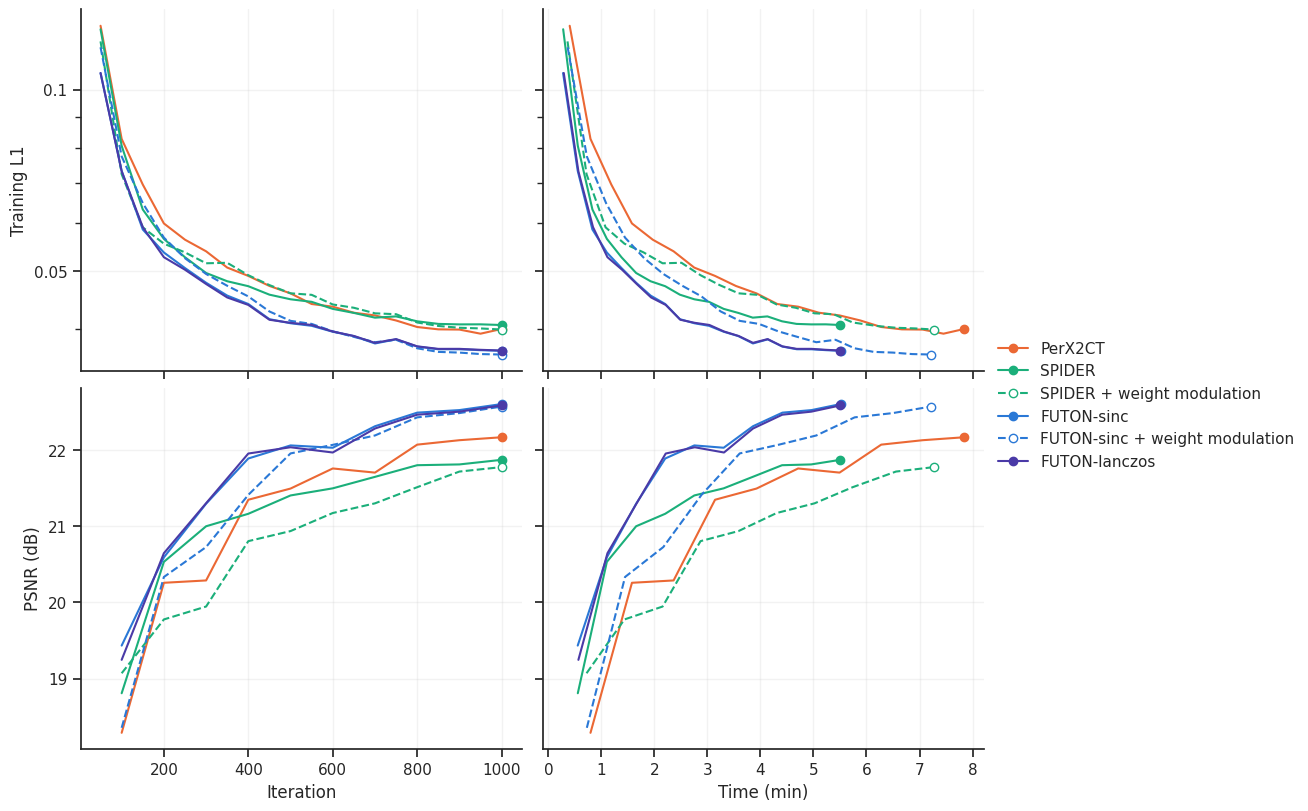

In [7]:
fig, axes = plt.subplots(
    2, 2, figsize=(13, 8), sharex="col", sharey="row", layout="constrained"
)

for row, metric in enumerate(["Training L1", "PSNR (dB)"]):
    curves = records.dropna(subset=[metric]).groupby("Model", sort=False)
    for col, x in enumerate(["Iteration", "Time (min)"]):
        for name, curve in curves:
            axes[row, col].plot(curve[x], curve[metric], markevery=[-1], **look(name))
        axes[row, col].set(xlabel=x, ylabel=metric)
        axes[row, col].label_outer()
axes[0, 0].set_yscale("log")
axes[0, 0].yaxis.set(  # ticks at 1, 2, 3 and 5 times a power of ten
    major_locator=LogLocator(subs=(1, 2, 3, 5)),
    major_formatter="{x:g}",
    minor_formatter=NullFormatter(),
)
fig.legend(
    *axes[0, 0].get_legend_handles_labels(), loc="outside right center", frameon=False
)

plt.show()

## Results Summary

PSNR and SSIM over the whole volume, on the 80 test patients, against the
training time, the throughput and the size of each model.

In [8]:
summary = pd.DataFrame(
    [
        {
            "Model": res["name"],
            "# Params (M)": res["num_params"] / 1e6,
            "Time (min)": res["history"][-1]["time"] / 60,
            "Throughput (vol/s)": res["speed"],
            **res["test"],
        }
        for res in results
    ]
)
ranking = summary.sort_values("PSNR (dB)", ascending=False, ignore_index=True)
display(ranking)

,Model,# Params (M),Time (min),Throughput (vol/s),PSNR (dB),SSIM
0,FUTON-sinc,2.732705,5.511361,2.256726,22.633275,0.657557
1,FUTON-lanczos,2.732705,5.506762,2.699464,22.626289,0.656875
2,FUTON-sinc + weight modulation,12.025131,7.216750,1.824270,22.555663,0.661623
3,PerX2CT,11.273249,7.842345,2.224168,22.232291,0.627593
4,SPIDER,6.219745,5.506031,1.354618,21.949303,0.635156
5,SPIDER + weight modulation,14.860059,7.273920,1.183018,21.819948,0.631035


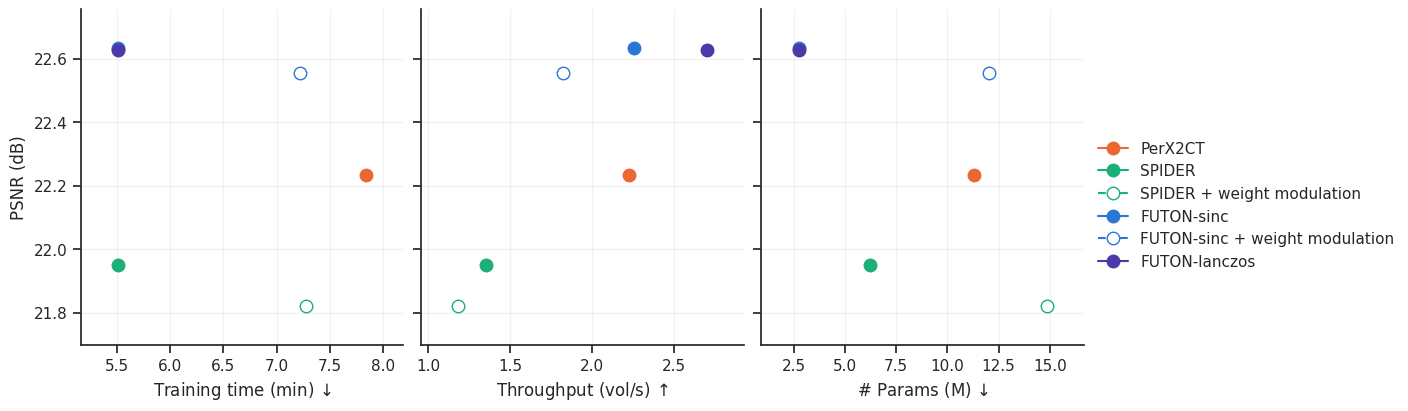

In [9]:
COSTS = {  # the arrow points to the better side
    "Time (min)": r"Training time (min)$\,\downarrow$",
    "Throughput (vol/s)": r"Throughput (vol/s)$\,\uparrow$",
    "# Params (M)": r"# Params (M)$\,\downarrow$",
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, layout="constrained")

for ax, (cost, label) in zip(axes, COSTS.items()):
    for _, model in summary.iterrows():
        ax.plot(model[cost], model["PSNR (dB)"], markersize=9, **look(model["Model"]))
    ax.set(xlabel=label, ylabel="PSNR (dB)")
    ax.label_outer()
    ax.margins(0.15)
fig.legend(
    *axes[0].get_legend_handles_labels(), loc="outside right center", frameon=False
)

plt.show()

## Visual Comparison

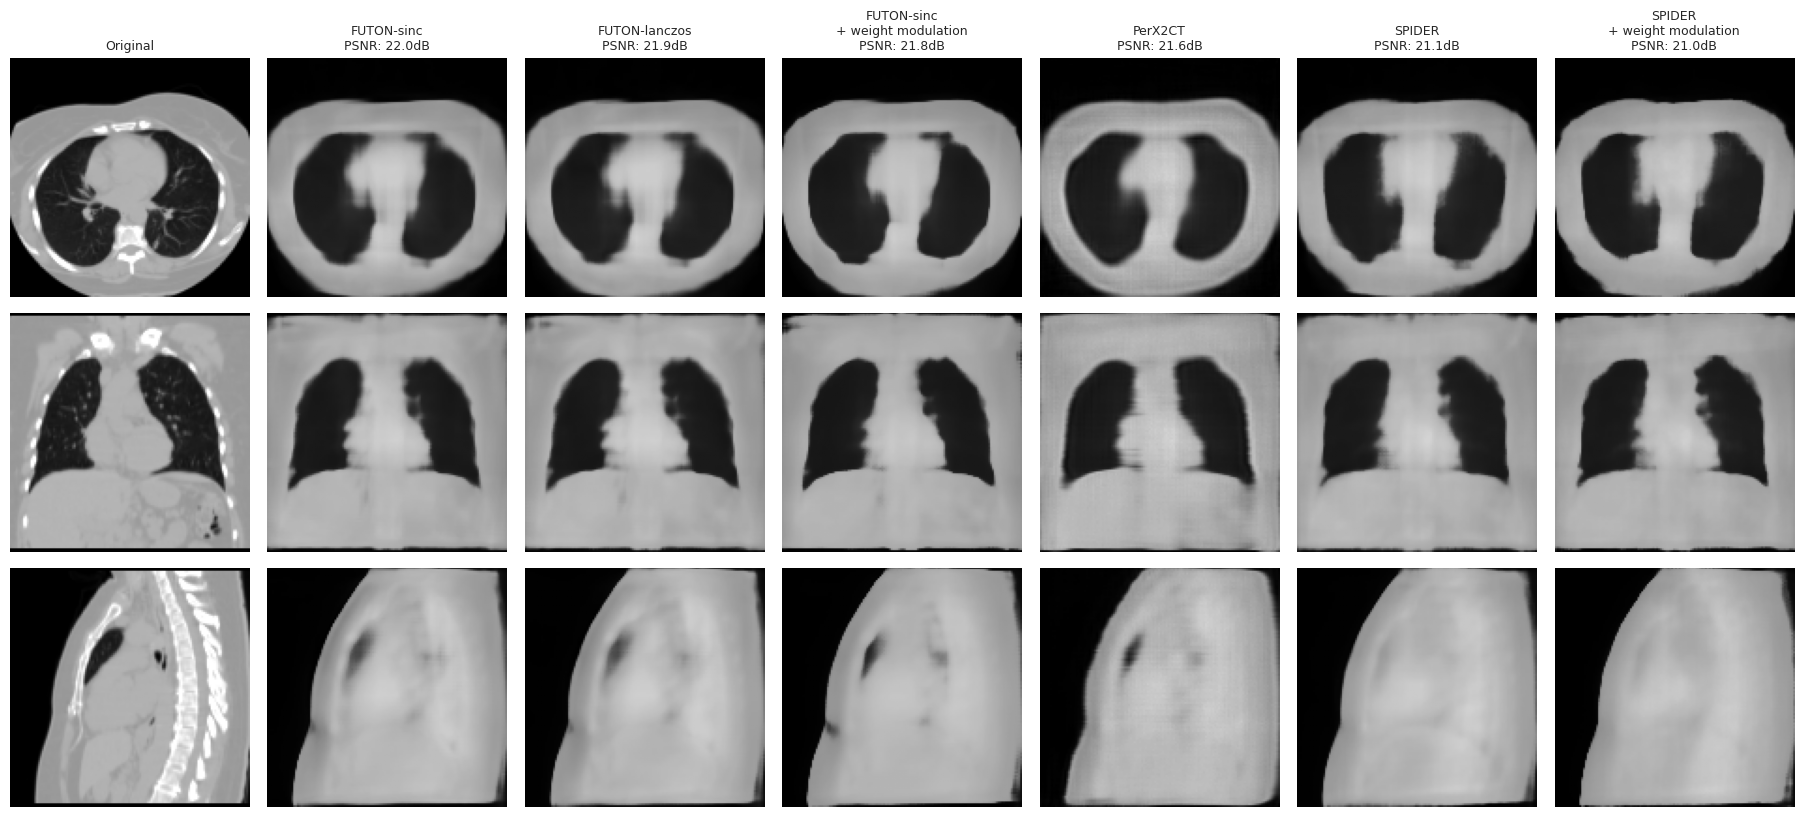

In [10]:
reconstructed = {res["name"]: res["reconstructed"] for res in results}
items = [("Original", volume[0])] + [
    (name, reconstructed[name]) for name in ranking["Model"]
]
fig, axes = plt.subplots(len(PLANES), len(items), figsize=(2.6 * len(items), 8.4))

for col, (name, recon) in enumerate(items):
    for row, cut in enumerate(PLANES.values()):
        axes[row, col].imshow(cut(recon), **WINDOW)
        axes[row, col].axis("off")
    psnr = 10 * torch.log10(1 / torch.mean((recon - volume[0]) ** 2))
    title = (
        name
        if name == "Original"
        else f"{name.replace(' + ', chr(10) + '+ ')}\nPSNR: {psnr:.1f}dB"
    )
    axes[0, col].set_title(title, fontsize=9)

plt.tight_layout()
plt.show()